In [1]:
# import requests
import pandas as pd
import numpy as np
from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
# import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          
from sklearn.model_selection import TimeSeriesSplit


import itertools

import time
import yaml
pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

## 1. Data Preparation

In [2]:
df = pd.read_csv("italy_revenues_PREDICTION_DATASET_v2_DIFFERENCED.csv")


# Data Preprocessing

In [3]:
df['date'] = pd.to_datetime(df['Unnamed: 0'])
# X_columns = df.set_index('date')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [4]:
selected_columns = ['fixed_term_diff', 'employment_rate_diff', 'youth_employment_rate_diff',
                    'industry_production_prices_diff', 'diesel_price_diff', 'WorkingDays_diff', 'TotSales']

df_selected = df [selected_columns]

In [5]:
df_sales = df_selected[['TotSales']]
df_selected.drop('TotSales', axis = 1, inplace = True)

In [6]:
df_sales.dropna(axis= 0, inplace =True)
df_sales

,TotSales
date,
2014-02-01,"78,038,658.00"
2014-03-01,"84,094,082.00"
2014-04-01,"86,341,669.00"
2014-05-01,"90,493,760.00"
2014-06-01,"90,851,778.00"
...,...
2025-09-01,"207,871,871.00"
2025-10-01,"220,481,612.00"
2025-11-01,"219,885,862.00"


## Differencing TotSales

In [7]:
feature = 'TotSales'

test_staticist = adfuller(df_sales[feature])[0]
adf_criticatical_value_5perc = adfuller(df_sales[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_sales[f'{feature}_diff'] = df_sales[feature] - df_sales[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')   

-1.44 > -2.88 ==> The time series is NON stationary


In [8]:
df_sales.shape, df.shape

((144, 2), (156, 14))

In [9]:
df_sales.dropna(axis = 0, inplace = True)
df_selected.dropna(axis = 0, inplace = True)

In [10]:
df_sales.shape, df_selected.shape

((143, 2), (155, 6))

# Data Preparation

In [11]:
X_train = df_selected.iloc[:-12]#.drop('TotSales', axis = 1)
X_test = df_selected.iloc[-12:]#.drop('TotSales', axis = 1)

y_train = df_sales['TotSales_diff']
# y_test = df_sales.iloc[-12:]['TotSales_diff']

In [12]:
X_train.shape, X_test.shape, y_train.shape, # y_test.shape

((143, 6), (12, 6), (143,))

## 2. Model: SARIMAX

In [13]:
best_param_V1 = (1, 1, 0)
best_param_seasonal_V1 = (0, 1, 0, 12)

# best_param_V2 = (0, 2, 2)
# best_param_seasonal_V2 = (0, 2, 2, 12)

### 2.1 training

In [14]:
model = SARIMAX(y_train,
                exog=X_train, 
                order=best_param_V1,
                seasonal_order=best_param_seasonal_V1,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


h = 12  # forecast horizon

# Training
exog_train_pred = X_train.iloc[-h:]  # 121 months
 

forecast_res = results.get_forecast(
    steps=h,
    exog=exog_train_pred              # required if you used exog
)

y_pred_forecast_mean_train = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

In [15]:
y_train[-12:]

date
2025-02-01   -14,843,127.00
2025-03-01    14,287,146.00
2025-04-01     6,510,598.00
2025-05-01     1,146,047.00
2025-06-01     5,905,147.00
2025-07-01    12,050,889.00
2025-08-01   -64,185,452.00
2025-09-01    48,167,692.00
2025-10-01    12,609,741.00
2025-11-01      -595,750.00
2025-12-01     2,678,511.00
2026-01-01   -20,329,170.00
Name: TotSales_diff, dtype: float64

In [16]:
y_pred_forecast_mean_train

2026-02-01   -12,290,413.67
2026-03-01    13,458,275.49
2026-04-01     7,236,015.10
2026-05-01     1,157,062.18
2026-06-01     6,244,524.90
2026-07-01    12,239,340.55
2026-08-01   -63,927,629.71
2026-09-01    48,393,629.21
2026-10-01    12,850,333.64
2026-11-01      -361,893.48
2026-12-01     2,915,463.66
2027-01-01   -20,093,640.43
Freq: MS, Name: predicted_mean, dtype: float64

### 2.2 testing

In [17]:
#THE OLD ONE

h = 12  # forecast horizon

forecast_res_test = results.get_forecast(
                                            steps=h,
                                            exog=X_test      # required if you used exog
                                        )

y_pred_forecast_mean_test = forecast_res_test.predicted_mean
conf_int = forecast_res_test.conf_int(alpha=0.05)  # 95% CI

In [18]:
y_pred_forecast_mean_test

2026-02-01   -18,452,622.21
2026-03-01    22,808,311.41
2026-04-01    -7,371,750.15
2026-05-01       665,819.05
2026-06-01    12,940,552.84
2026-07-01     8,780,283.64
2026-08-01   -60,738,418.29
2026-09-01    51,275,705.81
2026-10-01       800,552.61
2026-11-01     9,306,684.34
2026-12-01    -6,171,974.74
2027-01-01   -22,954,769.78
Freq: MS, Name: predicted_mean, dtype: float64

In [19]:
y_original = df_sales['TotSales'].iloc[-13] 

In [20]:
# Reversing the difference:
anchor = df_sales['TotSales'].iloc[-13] 
final_forecast = y_pred_forecast_mean_test.cumsum() + anchor

In [21]:
final_forecast

2026-02-01   180,380,308.79
2026-03-01   203,188,620.20
2026-04-01   195,816,870.05
2026-05-01   196,482,689.09
2026-06-01   209,423,241.94
2026-07-01   218,203,525.58
2026-08-01   157,465,107.29
2026-09-01   208,740,813.10
2026-10-01   209,541,365.71
2026-11-01   218,848,050.05
2026-12-01   212,676,075.30
2027-01-01   189,721,305.52
Freq: MS, Name: predicted_mean, dtype: float64

In [22]:
y_pred_forecast_mean_test

2026-02-01   -18,452,622.21
2026-03-01    22,808,311.41
2026-04-01    -7,371,750.15
2026-05-01       665,819.05
2026-06-01    12,940,552.84
2026-07-01     8,780,283.64
2026-08-01   -60,738,418.29
2026-09-01    51,275,705.81
2026-10-01       800,552.61
2026-11-01     9,306,684.34
2026-12-01    -6,171,974.74
2027-01-01   -22,954,769.78
Freq: MS, Name: predicted_mean, dtype: float64

In [23]:
df_sales_pred = pd.concat([df_sales , final_forecast], axis = 1)
df_sales_pred['TotSales'] = df_sales_pred['TotSales'].fillna(df_sales_pred['predicted_mean'])
df_sales_pred = df_sales_pred[['TotSales']]
df_sales_pred

,TotSales
2014-03-01,"84,094,082.00"
2014-04-01,"86,341,669.00"
2014-05-01,"90,493,760.00"
2014-06-01,"90,851,778.00"
2014-07-01,"104,405,551.00"
...,...
2026-09-01,"208,740,813.10"
2026-10-01,"209,541,365.71"
2026-11-01,"218,848,050.05"
2026-12-01,"212,676,075.30"


In [24]:
df_selected

,fixed_term_diff,employment_rate_diff,youth_employment_rate_diff,industry_production_prices_diff,diesel_price_diff,WorkingDays_diff
date,,,,,,
2014-03-01,"71,808.00",0.17,0.93,-0.20,-0.01,1.00
2014-04-01,"26,839.00",-1.24,-0.73,-0.20,-0.00,-1.00
2014-05-01,"40,469.00",2.21,0.75,-0.10,0.00,1.00
2014-06-01,"181,246.00",-0.40,0.46,0.20,0.00,-1.00
2014-07-01,"-27,097.00",0.40,-0.15,-0.30,0.00,3.00
...,...,...,...,...,...,...
2026-09-01,694.57,0.43,0.09,-9.27,0.02,0.00
2026-10-01,"29,955.99",-0.26,0.15,-1.44,-0.01,-1.00
2026-11-01,"-45,283.39",0.28,-0.10,-10.42,0.01,1.00


In [25]:
# df = pd.concat([df,df_sales_pred], axis = 1)

In [26]:
df_sales_pred

df_sales_pred['date'] = df_sales_pred.index

df_sales_pred = df_sales_pred[['date','TotSales']]

In [27]:
# # df['TotSales'] = df_sales.TotSales.fillna(final_forecast)

# df['date'] = df.index

# df = df[['date', 'WorkingDays', 'fixed_term', 'employment_rate', 'youth_employment_rate',
#                 'industry_production_prices', 'diesel_price', 
#                 'TotSales']]

In [28]:
df_sales_pred

,date,TotSales
2014-03-01,2014-03-01,"84,094,082.00"
2014-04-01,2014-04-01,"86,341,669.00"
2014-05-01,2014-05-01,"90,493,760.00"
2014-06-01,2014-06-01,"90,851,778.00"
2014-07-01,2014-07-01,"104,405,551.00"
...,...,...
2026-09-01,2026-09-01,"208,740,813.10"
2026-10-01,2026-10-01,"209,541,365.71"
2026-11-01,2026-11-01,"218,848,050.05"
2026-12-01,2026-12-01,"212,676,075.30"


In [29]:
y_test = df_sales['TotSales']
y_pred_forecast_mean_test = df_sales_pred[-12:]['TotSales']

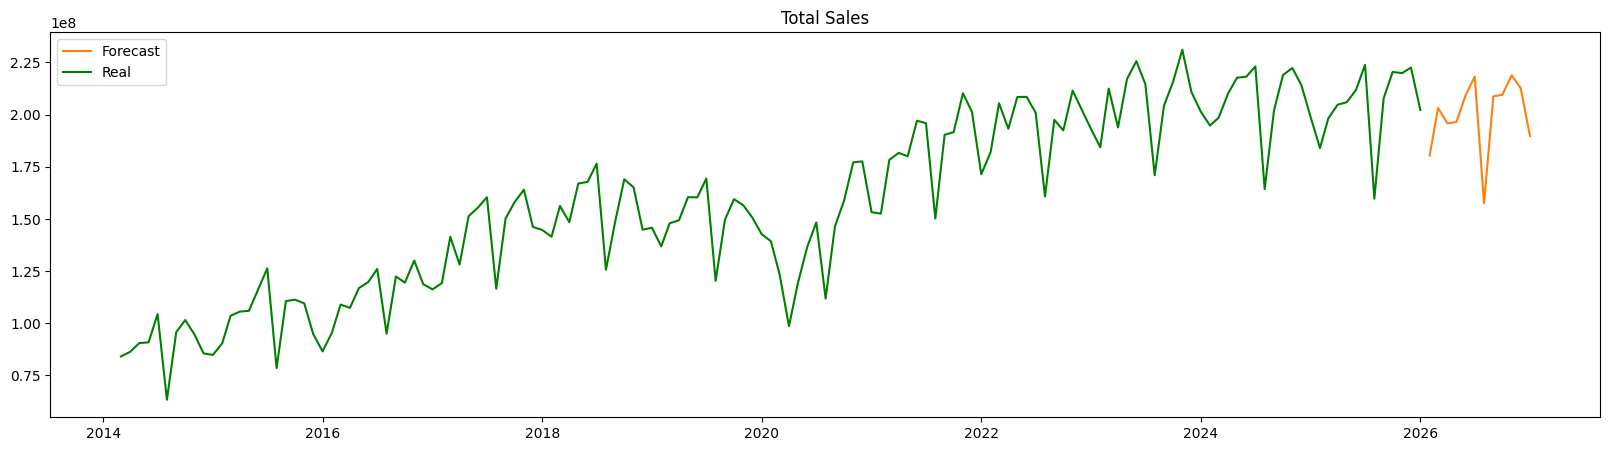

In [30]:
plt.figure(figsize=(20,5))

# plt.plot(y_train.index, y_train, label='Observed')
plt.plot(y_pred_forecast_mean_test.index, y_pred_forecast_mean_test, label='Forecast', color='C1')
plt.plot(y_test.index, y_test, label='Real', color = 'green')

# plt.fill_between(
#     y_pred_forecast_mean_test.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("Total Sales")
plt.show()

In [34]:
df_sales_pred

,date,TotSales
2014-03-01,2014-03-01,"84,094,082.00"
2014-04-01,2014-04-01,"86,341,669.00"
2014-05-01,2014-05-01,"90,493,760.00"
2014-06-01,2014-06-01,"90,851,778.00"
2014-07-01,2014-07-01,"104,405,551.00"
...,...,...
2026-09-01,2026-09-01,"208,740,813.10"
2026-10-01,2026-10-01,"209,541,365.71"
2026-11-01,2026-11-01,"218,848,050.05"
2026-12-01,2026-12-01,"212,676,075.30"


In [33]:
df_sales_pred.to_excel('Italy_revenues_predicted_2026_v2.xlsx', index=False)